<a href="https://colab.research.google.com/github/Dantebl/Pron-stico-de-ingresos-de-la-L-nea-A-del-metro-de-la-CDMX-usando-SARIMA/blob/main/Pronostico_Limpieza_y_modelo_SARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Módulo IV



# Proyecto Final

### La base de datos

In [ ]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
datos = pd.read_csv('/content/drive/MyDrive/Módulo IV/afluenciastc_2010a2024.csv')
datos.head()

,fecha,anio,mes,linea,estacion,afluencia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227
1,2010-01-01,2010,Enero,Linea 1,Isabel la Católica,6487
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304
3,2010-01-01,2010,Enero,Linea 1,Pino Suárez,8679
4,2010-01-01,2010,Enero,Linea 1,Gómez Farías,19499


### Proceso, limpieza y transformación de los datos

In [ ]:
datos['fecha'] = pd.to_datetime(datos['fecha'])
# Establecer la fecha límite para la multiplicación por 3
fecha_limite = pd.to_datetime('2013-12-12')

# Crear una nueva columna con las multiplicaciones según la fecha
datos['ganancia'] = datos.apply(
    lambda row: row['afluencia'] * 3 if row['fecha'] <= fecha_limite else row['afluencia'] * 5,
    axis=1
)

# Ver los primeros registros del DataFrame
print(datos.head())

       fecha  anio    mes    linea            estacion  afluencia  ganancia
0 2010-01-01  2010  Enero  Linea 1            Zaragoza      20227     60681
1 2010-01-01  2010  Enero  Linea 1  Isabel la Católica       6487     19461
2 2010-01-01  2010  Enero  Linea 1           Moctezuma      10304     30912
3 2010-01-01  2010  Enero  Linea 1         Pino Suárez       8679     26037
4 2010-01-01  2010  Enero  Linea 1        Gómez Farías      19499     58497


Nota: en el año del 2010 el precio del boleto era de 3 pesos, y a partir 13 de diciembre de  2013 se hizo el cambio de precio a 5 pesos.

In [ ]:
datos

,fecha,anio,mes,linea,estacion,afluencia,ganancia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227,60681
1,2010-01-01,2010,Enero,Linea 1,Isabel la Católica,6487,19461
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304,30912
3,2010-01-01,2010,Enero,Linea 1,Pino Suárez,8679,26037
4,2010-01-01,2010,Enero,Linea 1,Gómez Farías,19499,58497
...,...,...,...,...,...,...,...
1008730,2024-02-29,2024,Febrero,Línea B,Romero Rubio,16403,82015
1008731,2024-02-29,2024,Febrero,Línea B,Río de los Remedios,19512,97560
1008732,2024-02-29,2024,Febrero,Línea B,San Lázaro,17981,89905
1008733,2024-02-29,2024,Febrero,Línea B,Tepito,20752,103760


In [ ]:
# Revisión de valores nulos
datos.isnull().sum()

,0
fecha,0
anio,0
mes,6045
linea,0
estacion,0
afluencia,0
ganancia,0


se tiene valores nulos en el mes, pero estos no presentan un problema al no tener valores faltantes en la fecha

In [ ]:
# inconsistencia en los datos
print('Valores unicos por columna\n\n')
for col in datos.columns:
  print(f'{col}: {datos[col].unique()}\n\n')

Valores unicos por columna


fecha: <DatetimeArray>
['2010-01-01 00:00:00', '2010-01-02 00:00:00', '2010-01-03 00:00:00',
 '2010-01-04 00:00:00', '2010-01-05 00:00:00', '2010-01-06 00:00:00',
 '2010-01-07 00:00:00', '2010-01-08 00:00:00', '2010-01-09 00:00:00',
 '2010-01-10 00:00:00',
 ...
 '2024-02-20 00:00:00', '2024-02-21 00:00:00', '2024-02-22 00:00:00',
 '2024-02-23 00:00:00', '2024-02-24 00:00:00', '2024-02-25 00:00:00',
 '2024-02-26 00:00:00', '2024-02-27 00:00:00', '2024-02-28 00:00:00',
 '2024-02-29 00:00:00']
Length: 5173, dtype: datetime64[ns]


anio: [2010 2011 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023
 2024]


mes: ['Enero' 'Febrero' 'Marzo' 'Abril' 'Mayo' 'Junio' 'Julio' 'Agosto'
 'Septiembre' 'Octubre' 'Noviembre' 'Diciembre' nan]


linea: ['Linea 1' 'Linea 6' 'Linea 9' 'Linea 8' 'Linea 5' 'Linea 7' 'Linea 3'
 'Linea 4' 'Linea 2' 'Linea B' 'Linea 12' 'Linea A' 'Línea 1' 'Línea 12'
 'Línea 2' 'Línea 3' 'Línea 4' 'Línea 5' 'Línea 6' 'Línea 7' 'Línea 8'
 '

* Como ya se menciono anteriormente tenemos valores nulos en la columna representante al mes, pero como la columna de fecha no tiene ningun valor nulo no hay ningun problema en tener este valor faltante.


* En la columna de linea existen varios valores ya que como maximo deberia de existir 12 pero podemos ver que tenemos mas, este problema es debido a que tenemos escrito 'Linea' o 'Línea' el cual solo difiere en el acento de la 'i', por lo cual vamos a optar por quitar el acento para tener la consistencia de los datos.

In [ ]:
# unificado y reescribiendo las líneas
linea_map = {f'Línea {i}':f'Linea {i}' for i in [1,2,3,4,5,6,7,8,9,'A','B',12]}

datos['linea'] = datos['linea'].replace(linea_map)
datos['linea'].unique()

array(['Linea 1', 'Linea 6', 'Linea 9', 'Linea 8', 'Linea 5', 'Linea 7',
       'Linea 3', 'Linea 4', 'Linea 2', 'Linea B', 'Linea 12', 'Linea A'],
      dtype=object)

In [ ]:
#Haciendo una copia del DataFrame
df = datos.copy()
df

,fecha,anio,mes,linea,estacion,afluencia,ganancia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227,60681
1,2010-01-01,2010,Enero,Linea 1,Isabel la Católica,6487,19461
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304,30912
3,2010-01-01,2010,Enero,Linea 1,Pino Suárez,8679,26037
4,2010-01-01,2010,Enero,Linea 1,Gómez Farías,19499,58497
...,...,...,...,...,...,...,...
1008730,2024-02-29,2024,Febrero,Linea B,Romero Rubio,16403,82015
1008731,2024-02-29,2024,Febrero,Linea B,Río de los Remedios,19512,97560
1008732,2024-02-29,2024,Febrero,Linea B,San Lázaro,17981,89905
1008733,2024-02-29,2024,Febrero,Linea B,Tepito,20752,103760


In [ ]:
#normalización de las columnas
# Normalización Min-Max
df['afluencia_normalizada'] = (df['afluencia'] - df['afluencia'].min()) / (df['afluencia'].max() - df['afluencia'].min())
df['ganancia_normalizada'] = (df['ganancia'] - df['ganancia'].min()) / (df['ganancia'].max() - df['ganancia'].min())
df

,fecha,anio,mes,linea,estacion,afluencia,ganancia,afluencia_normalizada,ganancia_normalizada
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227,60681,0.076892,0.070870
1,2010-01-01,2010,Enero,Linea 1,Isabel la Católica,6487,19461,0.024660,0.022729
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304,30912,0.039170,0.036103
3,2010-01-01,2010,Enero,Linea 1,Pino Suárez,8679,26037,0.032993,0.030409
4,2010-01-01,2010,Enero,Linea 1,Gómez Farías,19499,58497,0.074125,0.068320
...,...,...,...,...,...,...,...,...,...
1008730,2024-02-29,2024,Febrero,Linea B,Romero Rubio,16403,82015,0.062356,0.095787
1008731,2024-02-29,2024,Febrero,Linea B,Río de los Remedios,19512,97560,0.074174,0.113942
1008732,2024-02-29,2024,Febrero,Linea B,San Lázaro,17981,89905,0.068354,0.105002
1008733,2024-02-29,2024,Febrero,Linea B,Tepito,20752,103760,0.078888,0.121183


In [ ]:
# Exportar el DataFrame a un archivo Excel
#df.to_excel('datosmetro.xlsx', index=False)  # index=False para no guardar el índice


In [ ]:
#from google.colab import files

# Descargar el archivo
#files.download('datosmetro.xlsx')

In [ ]:
linea_fecha = df[['linea','ganancia','fecha']].groupby(['linea','fecha'])\
                                                  .sum().sort_values(by=['linea','fecha'],)\
                                                  .reset_index()
linea_fecha['fecha'] = pd.to_datetime(linea_fecha['fecha'])
linea_fecha.set_index('fecha',inplace=True)

linea_fecha.head()

,linea,ganancia
fecha,,
2010-01-01,Linea 1,754422
2010-01-02,Linea 1,1533309
2010-01-03,Linea 1,1270221
2010-01-04,Linea 1,2309241
2010-01-05,Linea 1,2201859


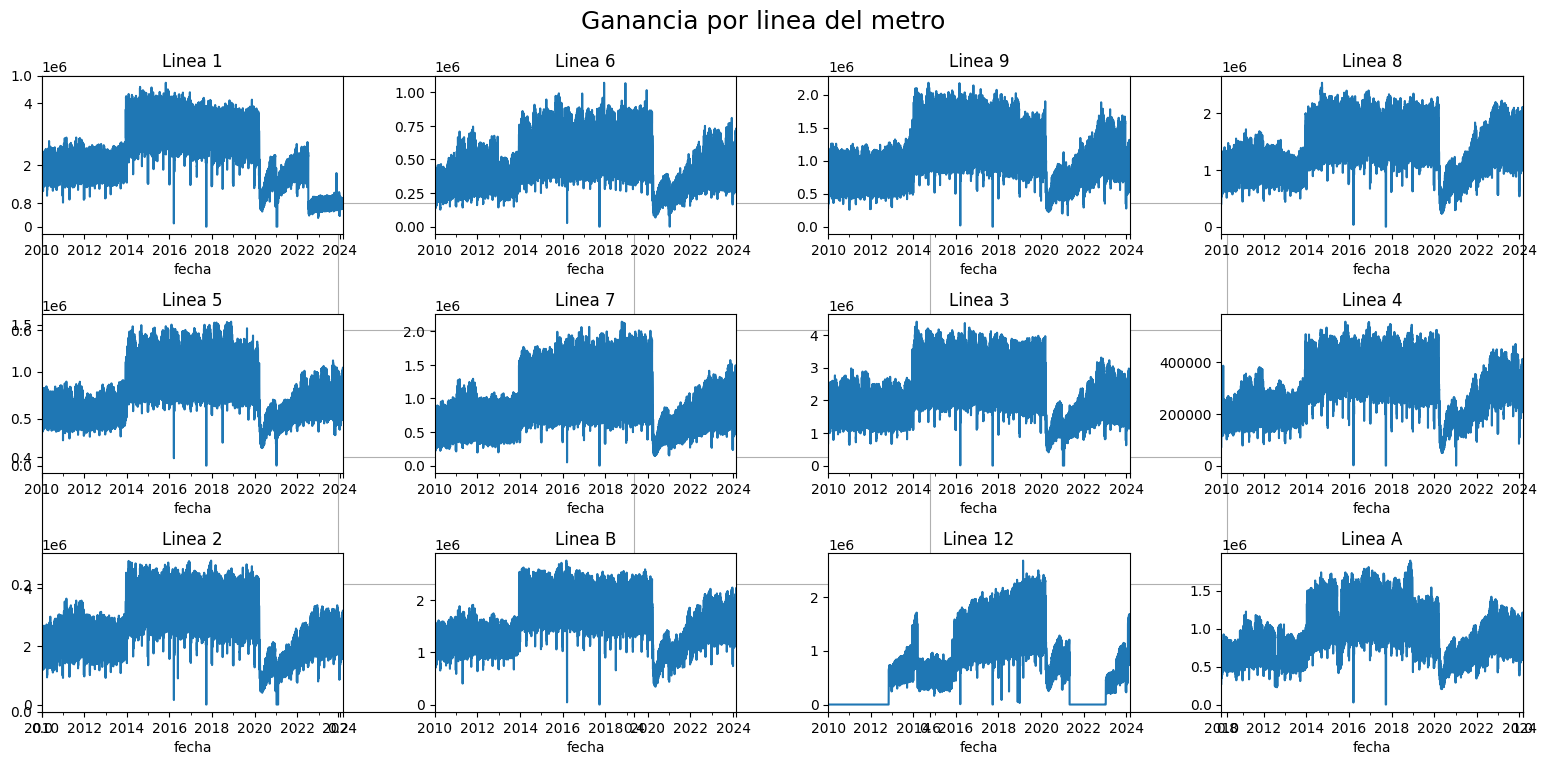

In [ ]:
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.suptitle('Ganancia por linea del metro', fontsize=18)
i=1
for linea in datos['linea'].unique():
  plt.subplot(3,4,i)
  linea_fecha[linea_fecha['linea'] == linea]['ganancia'].plot(figsize=(16,8))
  plt.title(f'{linea}')
  i +=1

plt.tight_layout()

Afluencia durante el covid-19

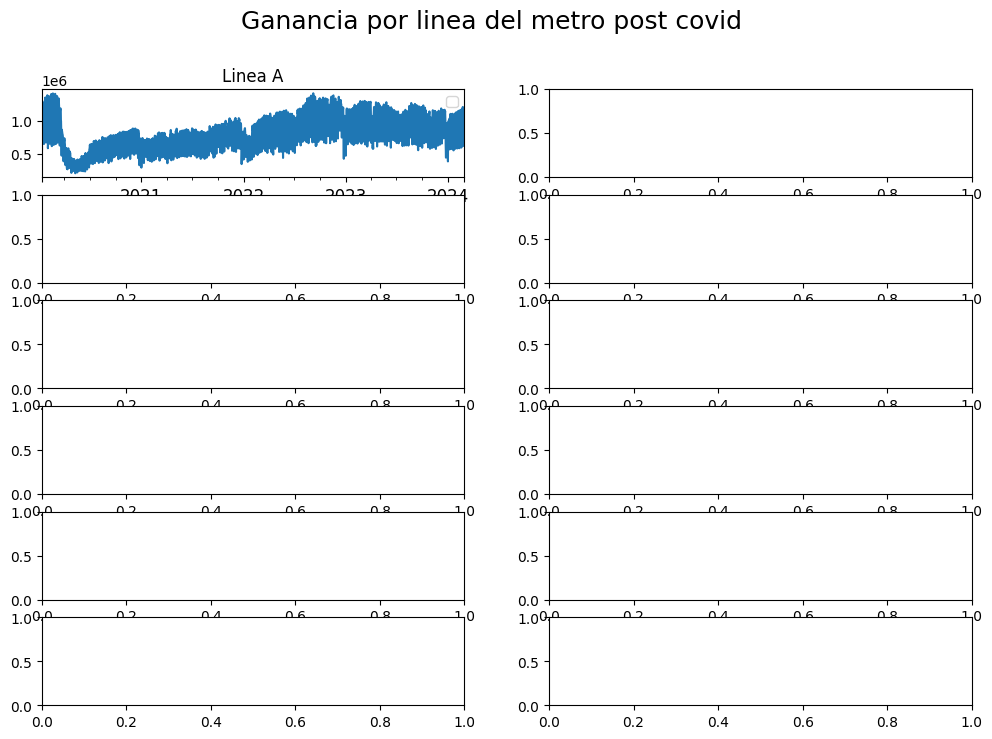

In [ ]:
i=0
fig, ax = plt.subplots(6,2, figsize=(20,20))
ax = ax.flatten()

plt.suptitle('Ganancia por linea del metro post covid', fontsize=18)

for linea in linea_fecha['linea'].unique():
  if linea == 'Linea A':
    linea_fecha.query('fecha >= "2020-01-11" and linea == @linea ').plot( y='ganancia',
                                                                  figsize=(12,8), ax=ax[i])
    ax[i].set_title(f'{linea}')
    ax[i].legend('')
    ax[i].tick_params(axis='x', labelsize=12)
    ax[i].set_xlabel("Fecha", fontsize=14)
    i +=1
  else:
    continue

# formato de fecha en eje X
#fig.autofmt_xdate()
#plt.tight_layout()

In [ ]:
i=0
fig, ax = plt.subplots(6,2, figsize=(20,20))


plt.legend('Ganancia por linea del metro post covid', fontsize=18)



linea_fecha.query('fecha >= "2020-01-11" and linea == @linea ').plot( y='ganancia',
                                                                  figsize=(12,8), ax=ax[i])
x[i].set_title(f'{linea}')
  ax[i].legend('')
  ax[i].tick_params(axis='x', labelsize=12)
  ax[i].set_xlabel("Fecha", fontsize=14)
  i +=1

# formato de fecha en eje X
fig.autofmt_xdate()
plt.tight_layout()

IndentationError: unexpected indent (<ipython-input-17-5ebf4871dae5>, line 12)

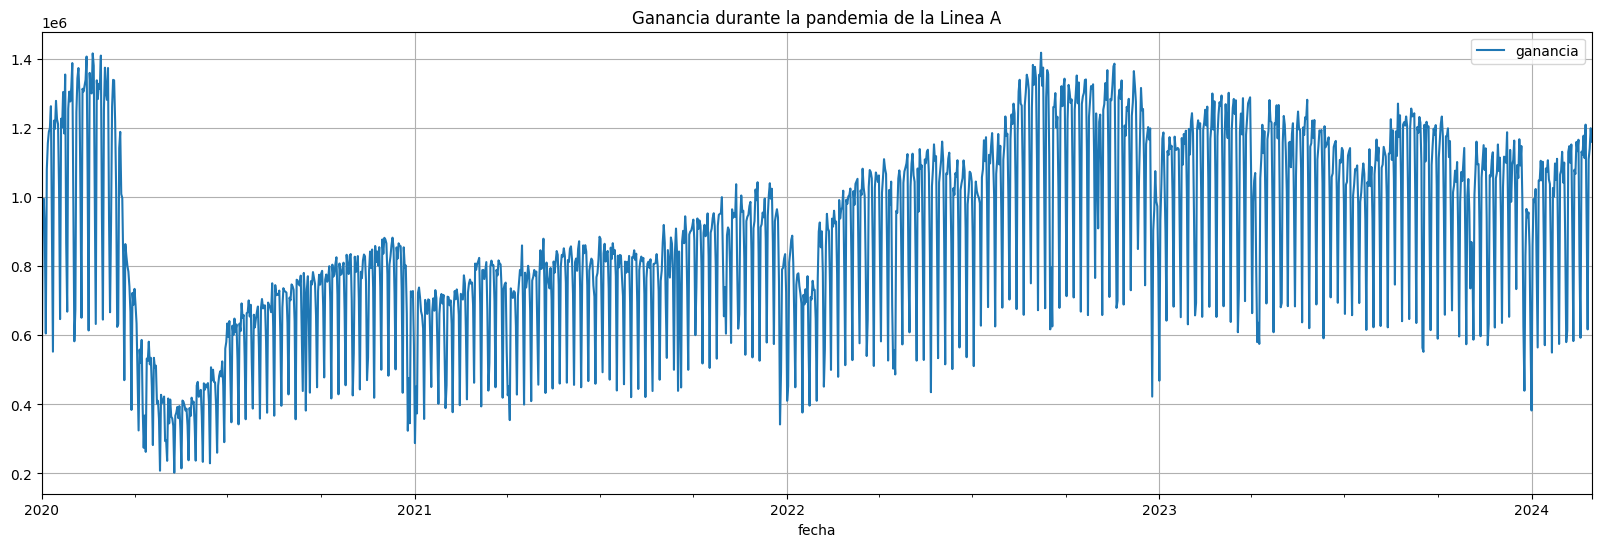

In [ ]:
linea_fecha.query('fecha >= "2020-01-01" and linea == "Linea A" ').plot( y='ganancia', figsize=(20,6))
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.title('Ganancia durante la pandemia de la Linea A');

**sugerencia:** ¿Sería una buena idea normalizar los datos?

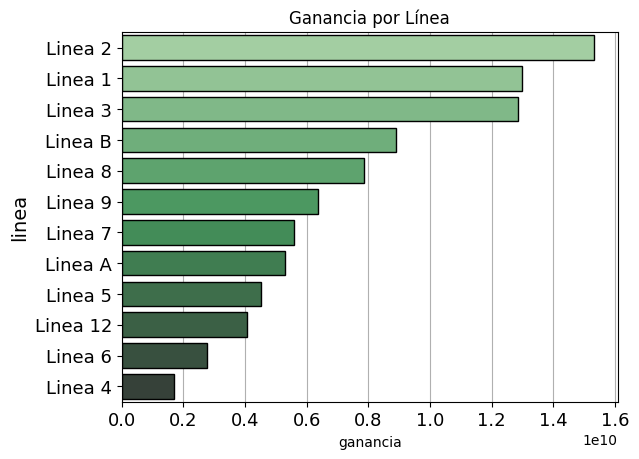

In [ ]:
#Lineas del metro con más ganancia
plt.grid(True)
plt.gca().set_axisbelow(True)
sns.barplot(df[['linea', 'ganancia']].groupby('linea').sum().sort_values(by='ganancia', ascending=False),
            y='linea',x='ganancia',hue='linea',
            palette='Greens_d', edgecolor='black')

plt.xticks(fontsize=13), plt.yticks(fontsize=13), plt.ylabel('linea',fontsize=14)
plt.title('Ganancia por Línea');

In [ ]:
datos.describe()

,fecha,anio,afluencia,ganancia
count,1008735,1.008735e+06,1.008735e+06,1.008735e+06
mean,2017-01-29 23:59:59.999999744,2.016587e+03,2.001732e+04,8.750370e+04
min,2010-01-01 00:00:00,2.010000e+03,0.000000e+00,0.000000e+00
25%,2013-07-17 00:00:00,2.013000e+03,7.456000e+03,3.236000e+04
50%,2017-01-30 00:00:00,2.017000e+03,1.463500e+04,6.429600e+04
75%,2020-08-15 00:00:00,2.020000e+03,2.599150e+04,1.123440e+05
max,2024-02-29 00:00:00,2.024000e+03,2.630560e+05,8.562250e+05
std,NaN,4.086974e+00,1.985458e+04,8.872187e+04


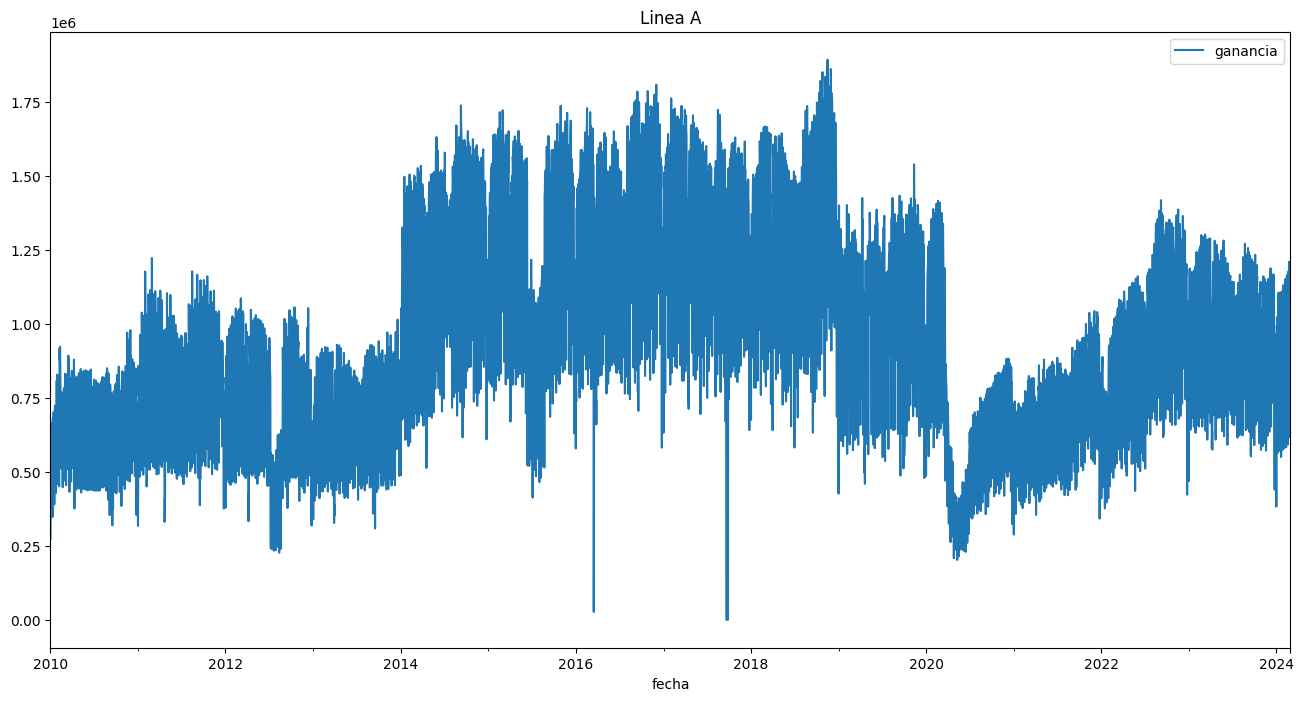

In [ ]:
linea_fecha[linea_fecha['linea'] == 'Linea A'][['ganancia']].plot(figsize=(16,8))
plt.title('Linea A');

In [ ]:
# Filtrar los datos solo para la "Línea A"
data_linea_a = datos[datos["linea"] == "Linea A"]

# Verificar las primeras filas del nuevo subconjunto
print(data_linea_a.head())

         fecha  anio    mes    linea           estacion  afluencia  ganancia
56  2010-01-01  2010  Enero  Linea A          Pantitlán      35151    105453
57  2010-01-01  2010  Enero  Linea A        Peñón Viejo       4047     12141
58  2010-01-01  2010  Enero  Linea A  Canal de San Juan       4182     12546
145 2010-01-01  2010  Enero  Linea A           Guelatao       7964     23892
147 2010-01-01  2010  Enero  Linea A             La Paz      11346     34038


In [ ]:
data_linea_a.describe()

,fecha,anio,afluencia,ganancia
count,51730,51730.000000,51730.000000,51730.000000
mean,2017-01-29 23:59:59.999999744,2016.586700,23278.429093,102400.673014
min,2010-01-01 00:00:00,2010.000000,0.000000,0.000000
25%,2013-07-17 00:00:00,2013.000000,11896.000000,50886.000000
50%,2017-01-30 00:00:00,2017.000000,16429.500000,71602.000000
75%,2020-08-15 00:00:00,2020.000000,25416.000000,108973.750000
max,2024-02-29 00:00:00,2024.000000,171245.000000,856225.000000
std,NaN,4.087011,22838.675417,105872.303684


##Sobre la linea A

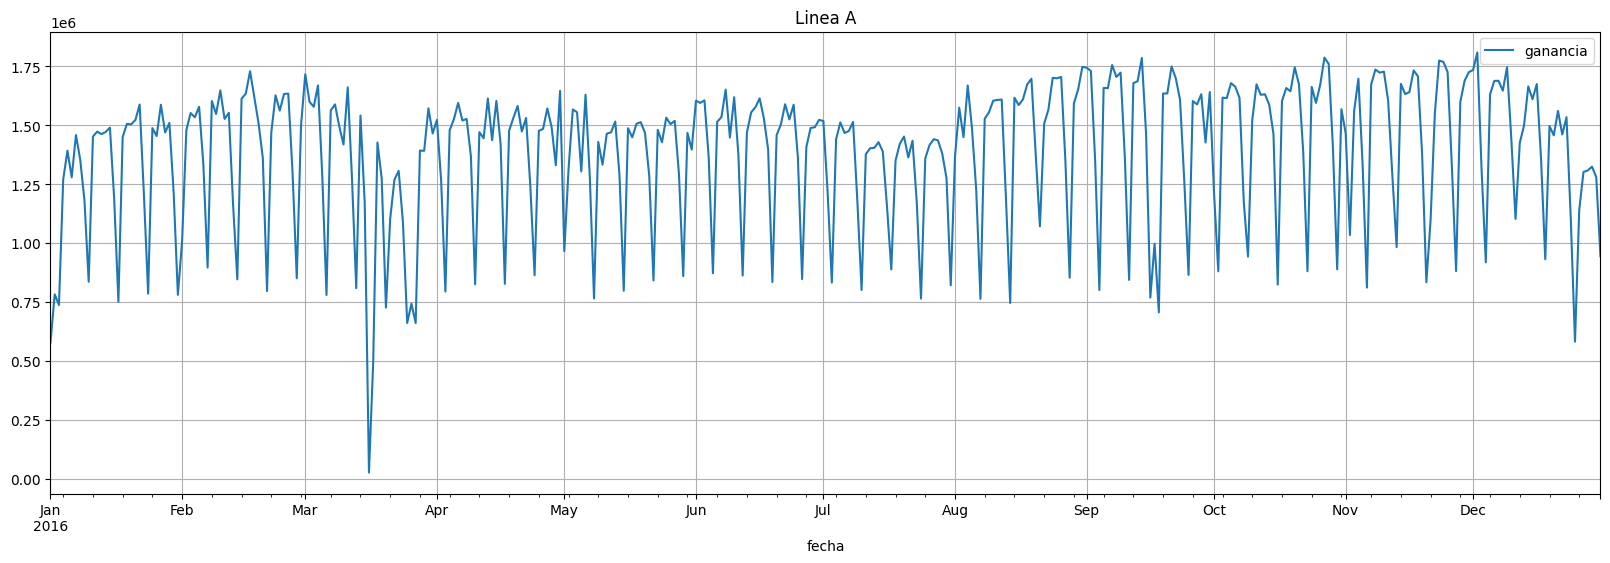

In [ ]:
linea_fecha.query('fecha >= "2016-01-01" and linea == "Linea A" and fecha < "2017-01-01" ').plot( y='ganancia', figsize=(20,6))
plt.grid(True)
plt.gca().set_axisbelow(True)
plt.title('Linea A');

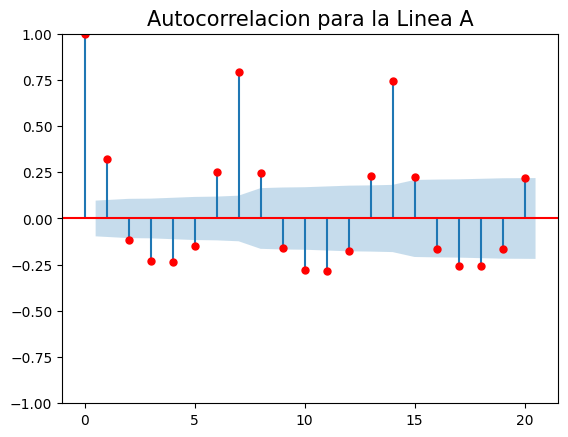

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(linea_fecha.query("linea == 'Linea A' and fecha >= '2023-01-15' ")['ganancia'],
           lags=20, color = 'r')
plt.title('Autocorrelacion para la Linea A',fontsize=15);

Linea A 

P-value asociado: 0.027
La linea es estacionaria
--------------------------------------------------


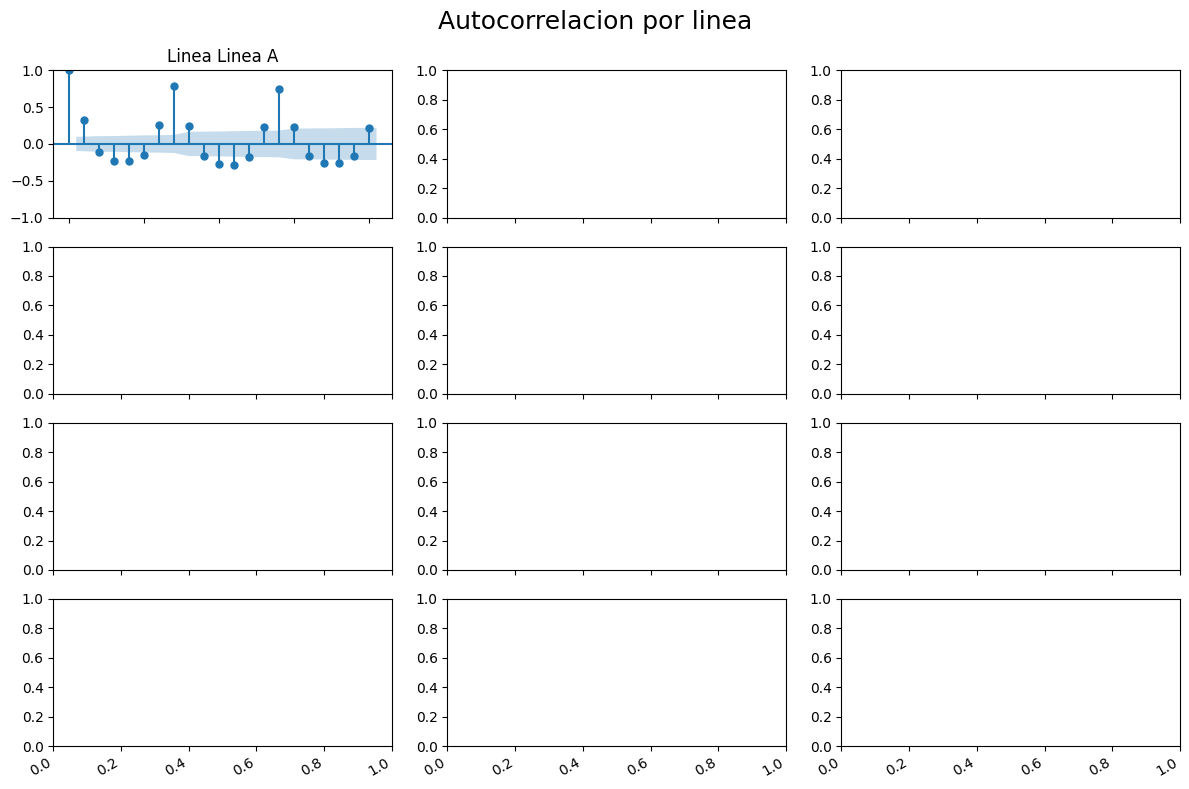

In [ ]:
# autocorrelación por linea
i = 0
fig, ax = plt.subplots(4,3, figsize=(12,8))
ax = ax.flatten()
plt.suptitle('Autocorrelacion por linea', fontsize= 18)

umbral = 0.05

for linea in linea_fecha['linea'].unique():
  if linea == 'Linea A':
    print(linea,'\n')

    value = adfuller(linea_fecha.query("linea == @linea and fecha >= '2023-01-15' ")['ganancia'])[1]
    print(f'P-value asociado: {value:.3f}')

    if value < umbral:
      print('La linea es estacionaria')

    else:
      print('La linea NO es estacionaria')

    print('-'*50)


    plot_acf(linea_fecha.query("linea == @linea and fecha >= '2023-01-15' ")['ganancia'],
           lags=20, ax=ax[i], )

    ax[i].set_title(f'Linea {linea}')
    i +=1

fig.autofmt_xdate()
plt.tight_layout()

In [ ]:
# Autocorrelación y autocorrelación parcial
# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(data_linea_a['Precio'].tolist(), lags=50, ax=axes[0])  #tolist() los datos los comvierta a una lista
plot_pacf(data_linea_a['Precio'].tolist(), lags=50, ax=axes[1]);

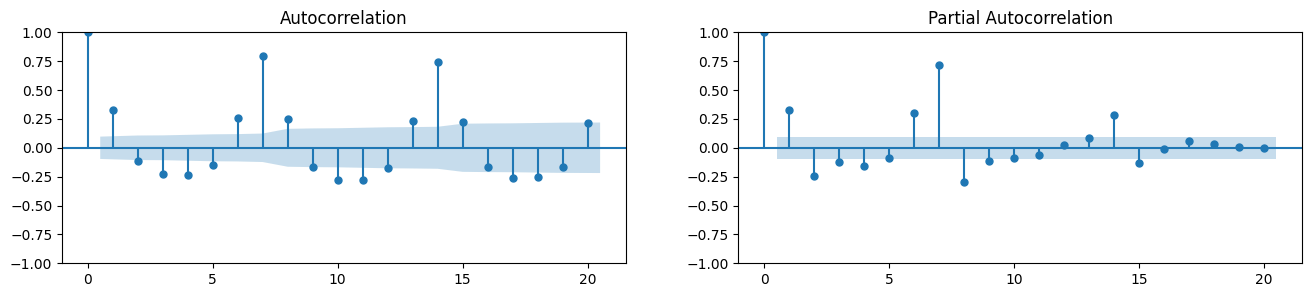

In [ ]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Autocorrelación y autocorrelación parcial
# Draw Plot
fig, axes = plt.subplots(1,2,figsize=(16,3), dpi= 100)
plot_acf(linea_fecha.query("linea == 'Linea A' and fecha >= '2023-01-15' ")['ganancia'].tolist(), lags=20, ax=axes[0])  #tolist() los datos los comvierta a una lista
plot_pacf(linea_fecha.query("linea == 'Linea A' and fecha >= '2023-01-15' ")['ganancia'].tolist(), lags=20, ax=axes[1]);

# Modelo Xgboost para la linea A

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Seleccionar columnas relevantes
columns_to_use = ["fecha"]
target_column = ["ganancia"]

# Codificar variables categóricas
label_encoder = LabelEncoder()
data_linea_a["estacion"] = label_encoder.fit_transform(data_linea_a["estacion"])
data_linea_a["mes"] = label_encoder.fit_transform(data_linea_a["mes"])

# Dividir en características (X) y variable objetivo (y)
X = data_linea_a[columns_to_use]
y = data_linea_a[target_column]

# Dividir en conjunto de entrenamiento y prueba
# Usar los últimos 30 registros para prueba
X_train = X.iloc[:-30]
y_train = y.iloc[:-30]
X_test = X.iloc[-30:]
y_test = y.iloc[-30:]


In [ ]:
#Entrenando al modelo
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Crear y entrenar el modelo
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

In [ ]:
# Predicciones en nuevos datos o en el conjunto de prueba
predictions = model.predict(X_test)
print(predictions[:10])  # Mostrar las primeras 10 predicciones

In [ ]:
# Comparar valores reales y predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Comparación: Valores reales vs. Predichos")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calcular RMSE y MAE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# Calcular RMSE y MAE porcentuales
average_actual = y_test.mean()
rmse_percentage = (rmse / average_actual) * 100
mae_percentage = (mae / average_actual) * 100

# Mostrar los resultados
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
# Calcular el MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

In [ ]:
correlation = data_linea_a[columns_to_use + [target_column]].corr()
print("Correlaciones:\n", correlation)

# Evaluar también RMSE
rmse = mean_squared_error(y_test, y_pred)
print(f"Root Mean Squared Error (RMSE): {rmse}")

##Series de tiempo

##Se trata de una serie de tiempo estacinaria

In [ ]:
df1 = datos.copy()
df1.head()

,fecha,anio,mes,linea,estacion,afluencia,ganancia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,20227,60681
1,2010-01-01,2010,Enero,Linea 1,Isabel la Católica,6487,19461
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,10304,30912
3,2010-01-01,2010,Enero,Linea 1,Pino Suárez,8679,26037
4,2010-01-01,2010,Enero,Linea 1,Gómez Farías,19499,58497


In [ ]:
#hacer un data set sin afluencia
df1 = df1.drop('afluencia', axis=1)
df1

,fecha,anio,mes,linea,estacion,ganancia
0,2010-01-01,2010,Enero,Linea 1,Zaragoza,60681
1,2010-01-01,2010,Enero,Linea 1,Isabel la Católica,19461
2,2010-01-01,2010,Enero,Linea 1,Moctezuma,30912
3,2010-01-01,2010,Enero,Linea 1,Pino Suárez,26037
4,2010-01-01,2010,Enero,Linea 1,Gómez Farías,58497
...,...,...,...,...,...,...
1008730,2024-02-29,2024,Febrero,Linea B,Romero Rubio,82015
1008731,2024-02-29,2024,Febrero,Linea B,Río de los Remedios,97560
1008732,2024-02-29,2024,Febrero,Linea B,San Lázaro,89905
1008733,2024-02-29,2024,Febrero,Linea B,Tepito,103760


In [ ]:
linea_fecha = df1[['linea','ganancia','fecha']].groupby(['linea','fecha'])\
                                                  .sum().sort_values(by=['linea','fecha'],)\
                                                  .reset_index()
linea_fecha['fecha'] = pd.to_datetime(linea_fecha['fecha'])
linea_fecha['año'] = linea_fecha['fecha'].dt.year
#'2020-04-30'
#2023-01-15'
linea_fecha=linea_fecha[linea_fecha['fecha']>= '2023-01-01']#
linea_fecha.set_index('fecha',inplace=True)

linea_fecha.head()

,linea,ganancia,año
fecha,,,
2023-01-01,Linea 1,343020,2023
2023-01-02,Linea 1,774830,2023
2023-01-03,Linea 1,810095,2023
2023-01-04,Linea 1,840060,2023
2023-01-05,Linea 1,991770,2023


In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.3 MB/s eta 0:00:00


In [ ]:
import pmdarima as pm

In [ ]:
linea_fecha

,linea,ganancia,año
fecha,,,
2023-01-01,Linea 1,343020,2023
2023-01-02,Linea 1,774830,2023
2023-01-03,Linea 1,810095,2023
2023-01-04,Linea 1,840060,2023
2023-01-05,Linea 1,991770,2023
...,...,...,...
2024-02-25,Linea B,1205620,2024
2024-02-26,Linea B,1978935,2024
2024-02-27,Linea B,1959605,2024


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=10263.748, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=10148.021, Time=1.00 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,1,1)(0,1,1)[7]             : AIC=10068.575, Time=0.60 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,1,2)(0,1,1)[7]             : AIC=10070.271, Time=1.10 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,1)(0,1,1)[7] intercept   : AIC=10068.121, Time=0.44 sec

Best model:  ARIMA(1,1,1)(0,1,1)[7]          
Total fit time: 18.475 seconds


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


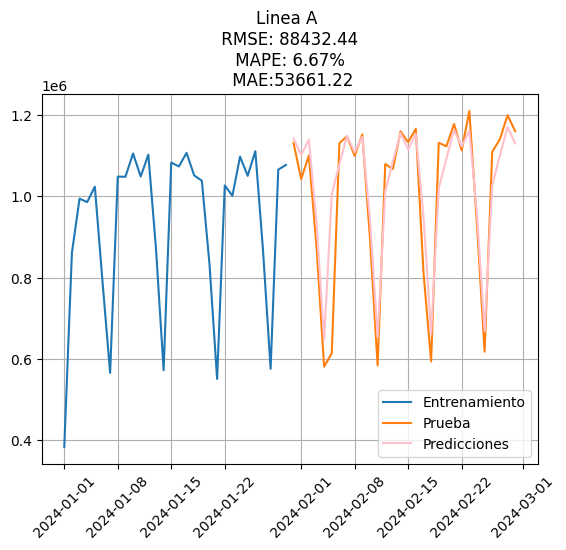

RMSE para la Linea A: 17684.32
Best Order: (1, 1, 1)
Best Seasonal Order: (0, 1, 1, 7)


In [ ]:
# Función para realizar la búsqueda de parámetros con AutoARIMA
def autoarima_model(train, test):
    # Ajuste automático de SARIMA
    modelo_auto = pm.auto_arima(train,
                                seasonal=True,
                                m=7,
                                stepwise=True,  # Búsqueda paso a paso para optimizar los parámetros
                                trace=True,  # Mostrar el progreso del ajuste
                                suppress_warnings=True,
                                start_p=0, start_q=0,
                                max_p=6, max_q=3,
                                start_P=0, start_Q=0,
                                max_P=6, max_Q=3,
                                d=1, D=1)

    # Hacer predicciones
    predicciones = modelo_auto.predict(n_periods=len(test))

    # Evaluar el modelo con RMSE
    rmse = np.sqrt(mean_squared_error(test, predicciones))

    return modelo_auto, predicciones, rmse

# Modelado por cada línea del metro
resultados = {}
lineas = linea_fecha['linea'].unique()

# Crea la figura y las subplots
#fig, axs = plt.subplots(3, 4, figsize=(32, 16))
#plt.gca().set_axisbelow(True)
#axs = axs.flatten()

linea = 'Linea A'

# Extraer la serie temporal de la línea
data = linea_fecha[linea_fecha['linea'] == linea][['ganancia']]

# Dividir en conjunto de entrenamiento y prueba
split = int(len(data) - 30)  # Últimos 30 datos para prueba
train, test = data[:split], data[split:]

# Ajuste automático con AutoARIMA
modelo_auto, predicciones, rmse = autoarima_model(train, test)

# Guardar solo métricas y parámetros
resultados[linea] = {
    'rmse': rmse,
    'best_order': modelo_auto.order,
    'best_seasonal_order': modelo_auto.seasonal_order
}
# Graficar en subplot correspondiente
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = np.mean(np.abs((test['ganancia'] - predicciones) / test['ganancia'])) * 100
mae = np.mean(np.abs(test['ganancia'] - predicciones))

# Graficar en subplot correspondiente
plt.plot(train[len(train)-30:], label='Entrenamiento')
plt.plot(test, label='Prueba')
plt.plot(test.index, predicciones, label='Predicciones', color='pink')
plt.title(f'{linea} \n RMSE: {rmse:.2f} \n MAPE: {mape:.2f}% \n MAE:{mae:.2f}')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()
# Liberar memoria para el modelo
#del modelo_auto
#gc.collect()
#plt.tight_layout()
#plt.show()

# Mostrar los errores RMSE para cada línea

print(f'RMSE para la {linea}: {info["rmse"]:.2f}')
print(f'Best Order: {info["best_order"]}')
print(f'Best Seasonal Order: {info["best_seasonal_order"]}')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

In [ ]:
# Extraer la serie temporal de la línea
data = linea_fecha[linea_fecha['linea'] == 'Linea A'][['ganancia']]

# Dividir en conjunto de entrenamiento y prueba
split = int(len(data) - 30)  # Últimos 30 datos para prueba
train, test = data[:split], data[split:]

# Ajustar el modelo SARIMA
modelo = SARIMAX(train, order=(6, 1, 1), seasonal_order=(1, 1, 1, 7))
modelo_fit = modelo.fit()

# Predicciones y evaluación
predicciones = modelo_fit.forecast(steps=len(test))
rmse = np.sqrt(mean_squared_error(test, predicciones))
mape = np.mean(np.abs((test['ganancia'] - predicciones) / test['ganancia'])) * 100
mae = np.mean(np.abs(test['ganancia'] - predicciones))
resultados["Linea A"] = rmse
# Graficar en subplot correspondiente
plt.plot(train[len(train)-30:], label='Entrenamiento')
plt.plot(test, label='Prueba')
plt.plot(test.index, predicciones, label='Predicciones', color='red')
plt.set_title(f'{linea} \n RMSE: {rmse:.2f} \n MAPE: {mape:.2f}% \n MAE:{mae:.2f}')
plt.legend()
plt.grid(True)

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

In [ ]:
umbral = 0.05

for linea in linea_fecha['linea'].unique():
  if linea == 'Linea A':
    print(linea,'\n')

    value = adfuller(linea_fecha.query("linea == @linea and fecha >= '2023-01-15' ")['ganancia'])[1]
    print(f'P-value asociado: {value:.3f}')

    if value < umbral:
      print('La linea es estacionaria')

    else:
      print('La linea NO es estacionaria')

    print('-'*50)


In [ ]:
plot_acf(linea_fecha.query("linea == 'Linea A' and fecha >= '2023-01-15' ")['ganancia'],
           lags=50, )
plt.title('Autocorrelacion para la linea A',fontsize=15);